In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Load dataset
df = pd.read_csv('cleaned_DOAS_urdaneta_2014_2021.csv')

# 2. Drop rows where the target (aqi) is missing
df = df.dropna(subset=['aqi']).reset_index(drop=True)

# 3. Impute remaining missing values across features
# Forward-fill / backward-fill preserves temporal continuity, followed by median for any edge cases
feature_cols = ['year', 'month', 'day', 'so2', 'nox', 'o3', 'pm10', 'co']
df[feature_cols] = df[feature_cols].ffill().bfill()
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# 4. Scale features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[feature_cols])
y_scaled = scaler_y.fit_transform(df[['aqi']])

# 5. Build sliding windows
window = 14


def create_sequences(X, y, window_size):
  X_seq, y_seq = [], []
  for i in range(len(X) - window_size):
    X_seq.append(X[i : i + window_size])
    y_seq.append(y[i + window_size])
  return np.array(X_seq), np.array(y_seq)


X_seq, y_seq = create_sequences(X_scaled, y_scaled, window)

# 6. Chronological split (80/20)
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [9]:
print('NaNs in X_train:', np.isnan(X_train).sum())
print('NaNs in y_train:', np.isnan(y_train).sum())
print('NaNs in X_test: ', np.isnan(X_test).sum())
print('NaNs in y_test: ', np.isnan(y_test).sum())

NaNs in X_train: 0
NaNs in y_train: 0
NaNs in X_test:  0
NaNs in y_test:  0


In [10]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Re-initialize the model to wipe out the corrupted NaN weights
model = tf.keras.Sequential([
    layers.Input(shape=(window, len(feature_cols))),
    layers.GRU(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.GRU(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.GRU(32),
    layers.Dropout(0.1),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='linear'),
])

# Add clipnorm=1.0 to prevent gradient explosions
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        filepath='best_gru_aqi.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=callbacks,
)

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0449 - mae: 0.1621
Epoch 1: val_loss improved from None to 0.06970, saving model to best_gru_aqi.keras

Epoch 1: finished saving model to best_gru_aqi.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0267 - mae: 0.1243 - val_loss: 0.0697 - val_mae: 0.2333
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0152 - mae: 0.0951
Epoch 2: val_loss improved from 0.06970 to 0.04090, saving model to best_gru_aqi.keras

Epoch 2: finished saving model to best_gru_aqi.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0146 - mae: 0.0914 - val_loss: 0.0409 - val_mae: 0.1766
Epoch 3/100
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0141 - mae: 0.0896
Epoch 3: val_loss improved from 0.04090 to 0.02562, saving model to best_gru_aqi.keras

Epoch 3: finished saving model to best_gru_aqi.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0139 - mae: 0.0885 - val_loss: 0.0256 - val_mae: 0.1376
Epoch 4/100
52/52 ━

In [11]:
# Predict on test set
y_pred_scaled = model.predict(X_test)

# Invert scale back to real AQI units
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Evaluate
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
print(f'Test AQI MAE:  {mae:.2f}')
print(f'Test AQI RMSE: {rmse:.2f}')

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Test AQI MAE:  11.60
Test AQI RMSE: 14.63


In [14]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

# 1. Load data
df = pd.read_csv('cleaned_DOAS_urdaneta_2014_2021.csv')
df = df.dropna(subset=['aqi']).copy()
df['date'] = pd.to_datetime(df['date'])
df['dayofweek'] = df['date'].dt.dayofweek

# 2. Select predictive features & impute gaps
features = ['month', 'day', 'dayofweek', 'so2', 'nox', 'o3', 'pm10', 'co']
X = df[features].ffill().bfill().fillna(df[features].median())
y = df['aqi']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Fit Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    bootstrap=True,
    max_features=0.6,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# 5. Evaluate
y_pred = rf_model.predict(X_test)
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'R-squared (R2) Variance Score: {r2_score(y_test, y_pred):.4f}')

# 6. Save model
joblib.dump(rf_model, 'optimized_rf_aqi_model.joblib')

Mean Absolute Error (MAE): 6.3517
Root Mean Squared Error (RMSE): 10.3510
R-squared (R2) Variance Score: 0.8424


['optimized_rf_aqi_model.joblib']

--- Philippine Clean Air Act 6-Class Classification Report ---
                         precision    recall  f1-score   support

                   Good       0.89      0.91      0.90       230
        Fair / Moderate       0.86      0.86      0.86       179
Unhealthy for Sensitive       0.25      0.14      0.18         7
         Very Unhealthy       0.00      0.00      0.00         3
      Acutely Unhealthy       0.00      0.00      0.00         0
              Emergency       0.00      0.00      0.00         0

               accuracy                           0.87       419
              macro avg       0.33      0.32      0.32       419
           weighted avg       0.86      0.87      0.87       419



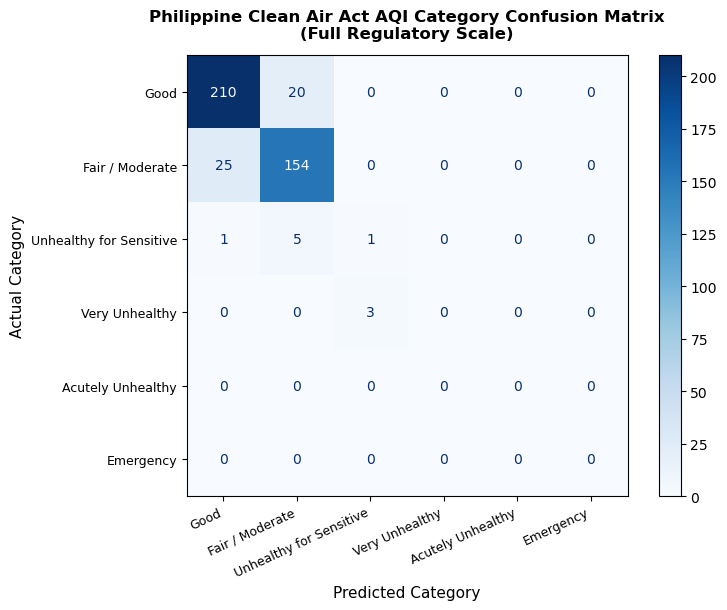

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

# 1. Define the full 6 Philippine Clean Air Act categories
all_categories = [
    'Good',
    'Fair / Moderate',
    'Unhealthy for Sensitive',
    'Very Unhealthy',
    'Acutely Unhealthy',
    'Emergency',
]


def to_ph_aqi_category(val):
  if pd.isna(val):
    return None
  elif val <= 50:
    return 'Good'
  elif val <= 100:
    return 'Fair / Moderate'
  elif val <= 150:
    return 'Unhealthy for Sensitive'
  elif val <= 200:
    return 'Very Unhealthy'
  elif val <= 300:
    return 'Acutely Unhealthy'
  else:
    return 'Emergency'


y_test_cat = pd.Series(y_test).apply(to_ph_aqi_category)
y_pred_cat = pd.Series(y_pred).apply(to_ph_aqi_category)

# 2. Compute the complete 6x6 matrix (explicitly passing all_categories)
cm_full = confusion_matrix(y_test_cat, y_pred_cat, labels=all_categories)

# 3. Print the report
print('--- Philippine Clean Air Act 6-Class Classification Report ---')
print(
    classification_report(
        y_test_cat, y_pred_cat, labels=all_categories, zero_division=0
    )
)

# 4. Plot the full 6x6 Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_full, display_labels=all_categories
)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title(
    'Philippine Clean Air Act AQI Category Confusion Matrix\n(Full Regulatory'
    ' Scale)',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
plt.ylabel('Actual Category', fontsize=11)
plt.xlabel('Predicted Category', fontsize=11)
plt.xticks(rotation=25, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.subplots_adjust(bottom=0.25)
plt.savefig('full_6x6_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()